<div class="alert alert-block alert-success">

# **Conclusions**
This notebook turns the results of the four analysis notebooks into a short business report.
Every chart here answers one question and is saved to `assets/report/` for the README.

- **Growth**: how fast is Delivr growing?
- **Revenue drivers**: where does the revenue growth come from?
- **Loyalty**: do customers come back?
- **Eateries**: which restaurant partners make the money?
- **Customers**: is the profit spread out or concentrated?
- **Timing**: when do new users arrive?

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from utils.db_utils import run_query

pio.renderers.default = "png"       # drop this line to get interactive plotly charts

REPORT_DIR = Path("assets/report")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# ── report theme (dark surface, colour-blind safe palette) ──────────────────
SURFACE = "#1a1a19"
INK = "#ffffff"
INK_2 = "#c3c2b7"
MUTED = "#898781"
GRID = "#2c2c2a"
BASELINE = "#383835"
DIMMED = "#4a4945"                  # de-emphasised marks

BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#3987e5", "#d95926", "#199e70", "#c98500", "#d55181"

# every eatery keeps the same colour in every chart
EATERY_COLORS: dict[str, str] = {
    "Bean Me Up Scotty": BLUE,
    "Burgatorio": ORANGE,
    "The Moon Wok": AQUA,
    "Leaning Tower of Pizza": YELLOW,
    "Life of Pie": MAGENTA,
}

FONT = "Segoe UI, system-ui, Arial, sans-serif"
WIDTH, HEIGHT = 1100, 480


def usd(text: str) -> str:
    """Escape '$' as an HTML entity. Two plain '$' in one string switch plotly into LaTeX mode."""
    return text.replace("$", "&#36;")


def style(fig: go.Figure, title: str, subtitle: str = "", height: int = HEIGHT) -> go.Figure:
    """Apply the report theme. The title states the takeaway, the subtitle the measure."""
    text = f"<b>{usd(title)}</b>"
    if subtitle:
        text += f"<br><span style='font-size:14px;color:{INK_2}'>{usd(subtitle)}</span>"
    fig.update_layout(
        title=dict(text=text, x=0.02, xanchor="left", y=0.95, yanchor="top",
                   font=dict(size=20, color=INK)),
        width=WIDTH, height=height,
        paper_bgcolor=SURFACE, plot_bgcolor=SURFACE,
        font=dict(family=FONT, size=13, color=INK_2),
        margin=dict(l=70, r=40, t=110, b=60),
        showlegend=False,
        bargap=0.35,
    )
    fig.update_xaxes(showgrid=False, linecolor=BASELINE, tickcolor=BASELINE,
                     tickfont=dict(color=MUTED), title_font=dict(color=INK_2))
    fig.update_yaxes(gridcolor=GRID, gridwidth=1, zeroline=False, linecolor=BASELINE,
                     tickfont=dict(color=MUTED), title_font=dict(color=INK_2))
    fig.update_annotations(font=dict(family=FONT))
    return fig


def save(fig: go.Figure, name: str) -> go.Figure:
    """Write the chart to assets/report/<name>.png and return it for display."""
    fig.write_image(REPORT_DIR / f"{name}.png", scale=2)
    return fig


def clean_eatery(df: pd.DataFrame, col: str = "eatery") -> pd.DataFrame:
    """Eatery names are stored with single quotes around them ('Burgatorio')."""
    df[col] = df[col].str.strip("'")
    return df


print("theme ready")

theme ready


In [2]:
# one monthly KPI table that several sections below reuse

monthly = run_query('''
WITH regs AS (
    SELECT user_id,
           date_trunc('month', min(order_date))::date AS reg_month
    FROM orders
    GROUP BY user_id
),
new_users AS (
    SELECT reg_month AS delivr_month,
           count(*)  AS new_users
    FROM regs
    GROUP BY reg_month
),
kpis AS (
    SELECT date_trunc('month', order_date)::date                  AS delivr_month,
           count(DISTINCT user_id)                                AS mau,
           count(DISTINCT order_id)                               AS orders,
           sum(meal_price * order_quantity)                       AS revenue,
           sum((meal_price - meal_cost) * order_quantity)         AS profit
    FROM orders
        INNER JOIN meals USING (meal_id)
    GROUP BY delivr_month
)
SELECT *
FROM kpis
    INNER JOIN new_users USING (delivr_month)
ORDER BY delivr_month;
''')

monthly["month"] = pd.to_datetime(monthly["delivr_month"]).dt.strftime("%b")
monthly["orders_per_user"] = monthly["orders"] / monthly["mau"]
monthly["order_value"] = monthly["revenue"] / monthly["orders"]
monthly["margin_pct"] = monthly["profit"] / monthly["revenue"] * 100
monthly["mau_added"] = monthly["mau"].diff()
monthly["mau_growth_pct"] = monthly["mau"].pct_change() * 100
monthly.round(2)

,delivr_month,mau,orders,revenue,profit,new_users,month,orders_per_user,order_value,margin_pct,mau_added,mau_growth_pct
0,2018-06-01,123,282,6296.25,4073.50,123,Jun,2.29,22.33,64.70,NaN,NaN
1,2018-07-01,226,445,10169.75,6575.50,140,Jul,1.97,22.85,64.66,103.0,83.74
2,2018-08-01,337,670,15340.00,9974.25,157,Aug,1.99,22.90,65.02,111.0,49.12
3,2018-09-01,489,1005,23819.50,15339.50,176,Sep,2.06,23.70,64.40,152.0,45.10
4,2018-10-01,689,1549,35576.25,23087.50,199,Oct,2.25,22.97,64.90,200.0,40.90
5,2018-11-01,944,2584,60130.00,38743.00,231,Nov,2.74,23.27,64.43,255.0,37.01
6,2018-12-01,1267,4816,108895.00,70300.50,278,Dec,3.80,22.61,64.56,323.0,34.22


<div class="alert alert-block alert-success">

## **1. Growth**: Delivr adds more users every month, but the growth rate is falling
- **MAU** (monthly active users) = distinct users who ordered at least once in the month
- Users added = this month's MAU minus last month's MAU
- Growth rate = users added divided by last month's MAU

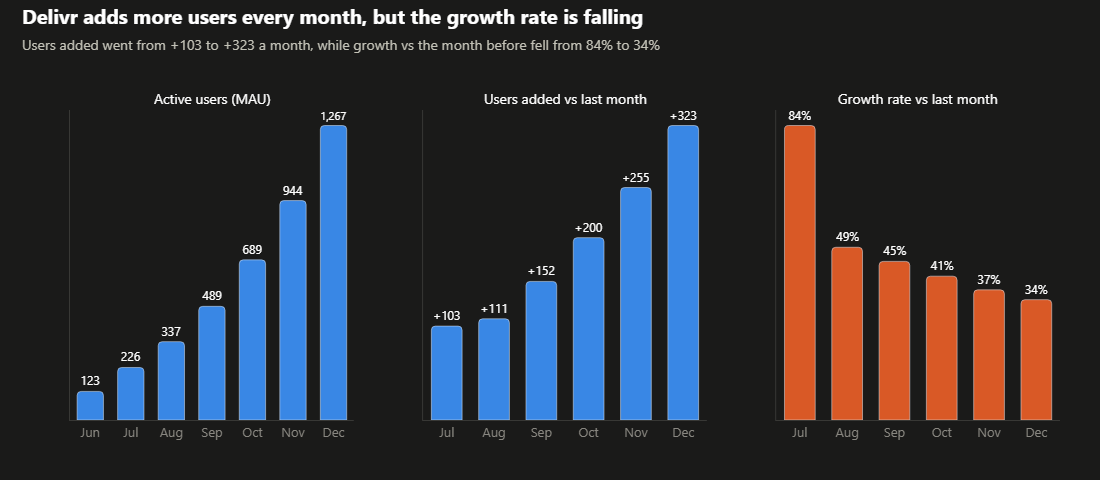

In [3]:
growth = monthly.dropna(subset=["mau_added"])

fig = make_subplots(
    rows=1, cols=3, horizontal_spacing=0.07,
    subplot_titles=("Active users (MAU)", "Users added vs last month", "Growth rate vs last month"),
)
fig.add_bar(x=monthly["month"], y=monthly["mau"], marker_color=BLUE,
            text=monthly["mau"].map("{:,.0f}".format), textposition="outside", row=1, col=1)
fig.add_bar(x=growth["month"], y=growth["mau_added"], marker_color=BLUE,
            text=growth["mau_added"].map("+{:,.0f}".format), textposition="outside", row=1, col=2)
fig.add_bar(x=growth["month"], y=growth["mau_growth_pct"], marker_color=ORANGE,
            text=growth["mau_growth_pct"].map("{:.0f}%".format), textposition="outside", row=1, col=3)

style(fig, "Delivr adds more users every month, but the growth rate is falling",
      "Users added went from +103 to +323 a month, while growth vs the month before fell from 84% to 34%")
fig.update_traces(textfont=dict(color=INK, size=12), cliponaxis=False, marker_cornerradius=4)
fig.update_yaxes(showticklabels=False, showgrid=False)
fig.update_annotations(font=dict(size=14, color=INK))
save(fig, "01_growth")

<div class="alert alert-block alert-success">

## **2. Revenue drivers**: where does the revenue growth come from?
Monthly revenue can be split into three parts:

$$\textit{Revenue} = \textit{active users} \times \textit{orders per user} \times \textit{average order value}$$

The waterfall shows how many dollars of monthly revenue (June to December) each part added.
- Changing the parts one at a time gives a different split for every order of the steps (users first gives users 57%, orders per user first gives users 95%)
- So the split is the **average over all 6 possible orders** (a Shapley split). Each part gets its fair share, and the three shares always add up to the full growth

{'mau': '78,360 (76.4%)', 'orders_per_user': '23,596 (23.0%)', 'order_value': '642 (0.6%)'}


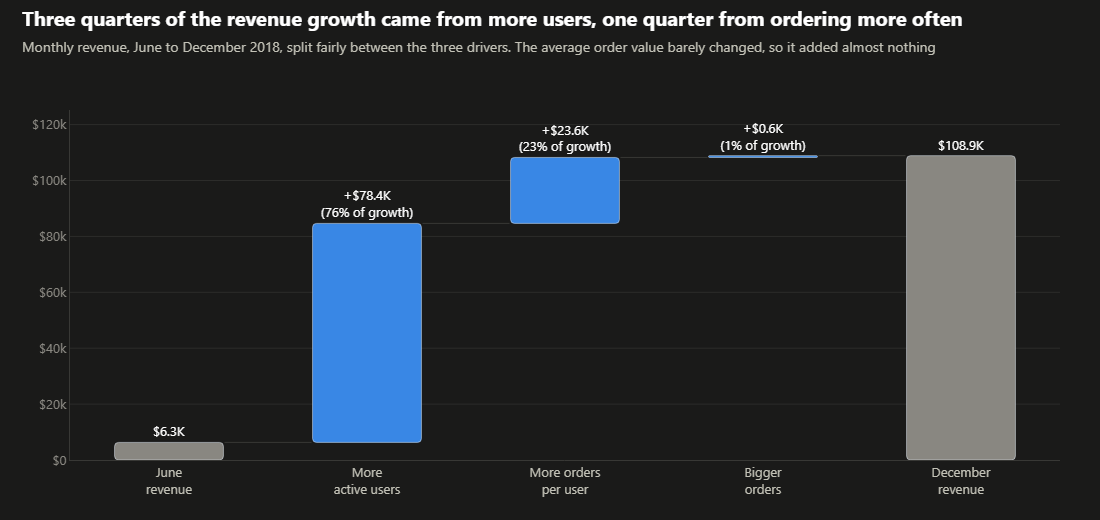

In [4]:
from itertools import permutations

jun, dec = monthly.iloc[0], monthly.iloc[-1]
drivers = {                               # column in `monthly` -> label on the chart
    "mau": "More<br>active users",
    "orders_per_user": "More orders<br>per user",
    "order_value": "Bigger<br>orders",
}


def revenue_of(state: dict[str, float]) -> float:
    """Revenue = active users x orders per user x average order value."""
    return state["mau"] * state["orders_per_user"] * state["order_value"]


# Shapley split: for every order of the steps, switch the drivers from June to December
# one at a time and record what each switch adds. Each driver's share is its average.
step_orders = list(permutations(drivers))
contribution = {d: 0.0 for d in drivers}
for step_order in step_orders:
    state = {d: jun[d] for d in drivers}
    for d in step_order:
        before = revenue_of(state)
        state[d] = dec[d]
        contribution[d] += (revenue_of(state) - before) / len(step_orders)

rev_jun, rev_dec = jun["revenue"], dec["revenue"]
total_gain = rev_dec - rev_jun
heights = [rev_jun, *contribution.values(), rev_dec]
bases = [0, rev_jun, rev_jun + contribution["mau"],
         rev_jun + contribution["mau"] + contribution["orders_per_user"], 0]

steps = pd.DataFrame({
    "label": ["June<br>revenue", *drivers.values(), "December<br>revenue"],
    "base": bases,
    "height": heights,
    "color": [MUTED, BLUE, BLUE, BLUE, MUTED],
})
steps["text"] = [
    f"${h/1e3:.1f}K" if i in (0, 4) else f"+${h/1e3:.1f}K<br>({h/total_gain:.0%} of growth)"
    for i, h in enumerate(steps["height"])
]

fig = go.Figure(go.Bar(
    x=steps["label"], y=steps["height"], base=steps["base"], marker_color=steps["color"],
    text=steps["text"], textposition="outside", textfont=dict(color=INK, size=13),
    cliponaxis=False, marker_cornerradius=4, width=0.55,
))
# thin connectors between the top of one step and the start of the next
tops = (steps["base"] + steps["height"]).tolist()
for i in range(len(steps) - 1):
    fig.add_shape(type="line", x0=i + 0.28, x1=i + 0.72, y0=tops[i], y1=tops[i],
                  line=dict(color=BASELINE, width=1))

style(fig, "Three quarters of the revenue growth came from more users, one quarter from ordering more often",
      "Monthly revenue, June to December 2018, split fairly between the three drivers. "
      "The average order value barely changed, so it added almost nothing",
      height=520)
fig.update_yaxes(tickprefix="$", tickformat="~s", range=[0, rev_dec * 1.15])
fig.update_xaxes(tickfont=dict(color=INK_2, size=13))
print({d: f"{v:,.0f} ({v / total_gain:.1%})" for d, v in contribution.items()})
save(fig, "02_revenue_waterfall")

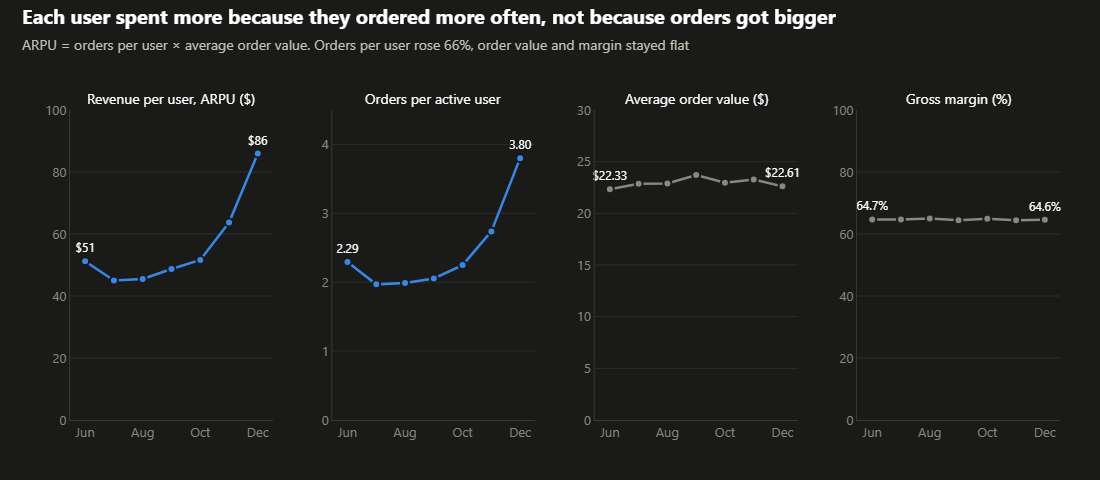

In [5]:
# what changed per user and per order? only the number of orders per user
monthly["arpu"] = monthly["revenue"] / monthly["mau"]

panels = [
    ("arpu", "Revenue per user, ARPU ($)", BLUE, "${:.0f}", [0, 100]),
    ("orders_per_user", "Orders per active user", BLUE, "{:.2f}", [0, 4.5]),
    ("order_value", "Average order value ($)", MUTED, "${:.2f}", [0, 30]),
    ("margin_pct", "Gross margin (%)", MUTED, "{:.1f}%", [0, 100]),
]
fig = make_subplots(rows=1, cols=4, horizontal_spacing=0.06, subplot_titles=[p[1] for p in panels])
for i, (col, _, color, fmt, yrange) in enumerate(panels, start=1):
    labels = [fmt.format(v) if j in (0, len(monthly) - 1) else "" for j, v in enumerate(monthly[col])]
    fig.add_scatter(x=monthly["month"], y=monthly[col], mode="lines+markers+text",
                    line=dict(color=color, width=2.5), marker=dict(size=8, color=color, line=dict(color=SURFACE, width=2)),
                    text=labels, textposition="top center", textfont=dict(color=INK, size=12),
                    cliponaxis=False, row=1, col=i)
    fig.update_yaxes(range=yrange, row=1, col=i)

style(fig, "Each user spent more because they ordered more often, not because orders got bigger",
      "ARPU = orders per user × average order value. Orders per user rose 66%, order value and margin stayed flat")
fig.update_annotations(font=dict(size=14, color=INK))
fig.update_xaxes(tickvals=["Jun", "Aug", "Oct", "Dec"])
save(fig, "03_per_user_vs_per_order")

<div class="alert alert-block alert-success">

## **3. Loyalty**: do customers come back?
Every active user in a month is one of three types:
- **New**: their first order was this month
- **Retained**: they also ordered last month
- **Resurrected**: they ordered before, skipped last month, and came back this month

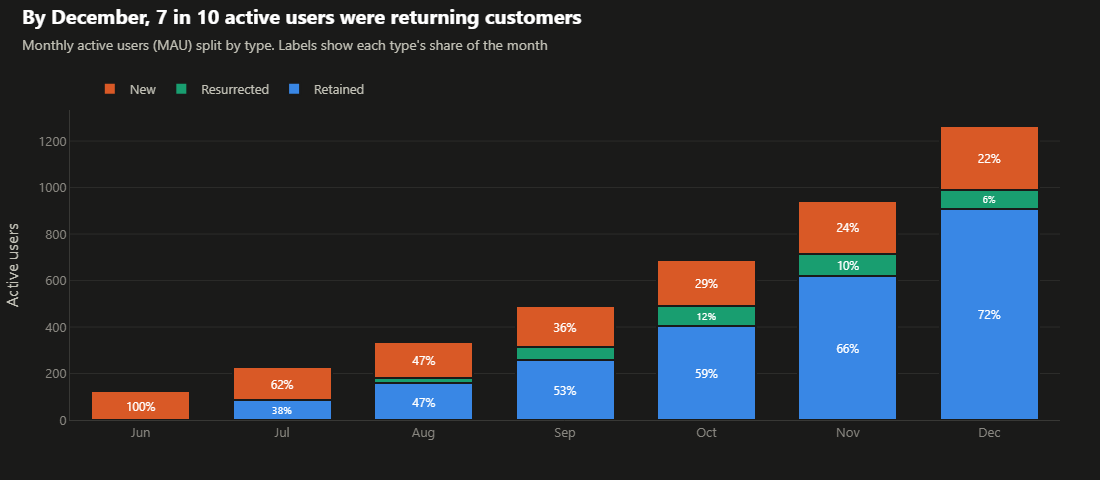

In [6]:
user_types = run_query('''
WITH activity AS (
    SELECT DISTINCT user_id,
           date_trunc('month', order_date)::date AS delivr_month
    FROM orders
),
first_month AS (
    SELECT user_id,
           min(delivr_month) AS reg_month
    FROM activity
    GROUP BY user_id
)
SELECT cur.delivr_month,
       CASE WHEN cur.delivr_month = fm.reg_month THEN 'New'
            WHEN prev.user_id IS NOT NULL THEN 'Retained'
            ELSE 'Resurrected'
       END                        AS user_type,
       count(*)                   AS users
FROM activity AS cur
    INNER JOIN first_month AS fm USING (user_id)
    LEFT JOIN activity AS prev ON prev.user_id = cur.user_id
        AND prev.delivr_month = (cur.delivr_month - interval '1 month')::date
GROUP BY cur.delivr_month, user_type
ORDER BY cur.delivr_month;
''')
user_types["month"] = pd.to_datetime(user_types["delivr_month"]).dt.strftime("%b")
user_types["share"] = user_types["users"] / user_types.groupby("delivr_month")["users"].transform("sum")

fig = go.Figure()
for user_type, color in [("Retained", BLUE), ("Resurrected", AQUA), ("New", ORANGE)]:
    part = user_types[user_types["user_type"] == user_type]
    # label a segment only when it is tall enough to hold the text
    text = [f"{s:.0%}" if u >= 70 else "" for s, u in zip(part["share"], part["users"])]
    fig.add_bar(x=part["month"], y=part["users"], name=user_type, marker_color=color,
                marker_line=dict(color=SURFACE, width=2),
                text=text, textposition="inside", insidetextanchor="middle",
                textfont=dict(color=INK, size=12))

style(fig, "By December, 7 in 10 active users were returning customers",
      "Monthly active users (MAU) split by type. Labels show each type's share of the month")
fig.update_layout(barmode="stack", showlegend=True, bargap=0.3,
                  legend=dict(orientation="h", x=0.02, y=1.02, yanchor="bottom", traceorder="reversed",
                              font=dict(color=INK_2, size=13)))
fig.update_xaxes(categoryorder="array", categoryarray=monthly["month"].tolist())
fig.update_yaxes(title="Active users")
save(fig, "04_active_user_types")

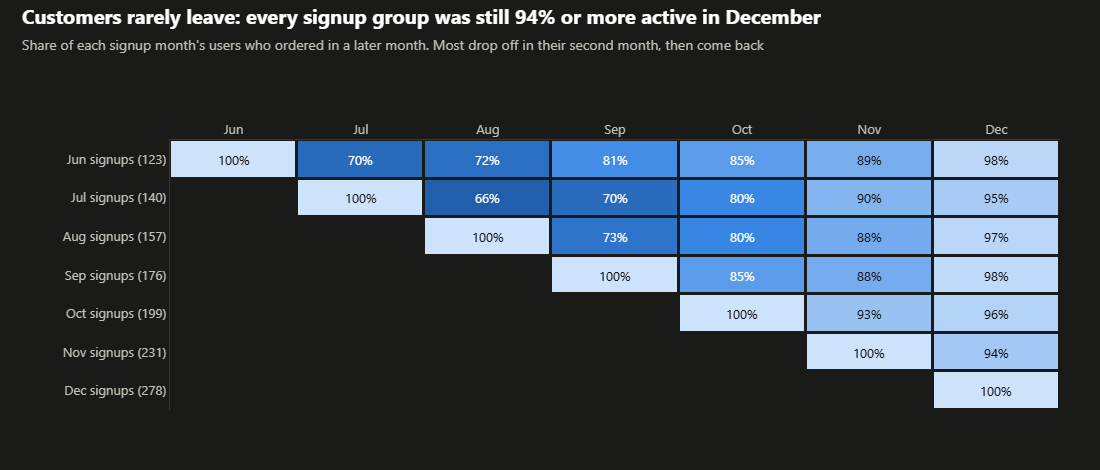

In [7]:
# cohort view: of the users who signed up in a month, what share ordered in each later month?
cohorts = run_query('''
WITH activity AS (
    SELECT DISTINCT user_id,
           date_trunc('month', order_date)::date AS delivr_month
    FROM orders
),
first_month AS (
    SELECT user_id,
           min(delivr_month) AS reg_month
    FROM activity
    GROUP BY user_id
)
SELECT fm.reg_month,
       a.delivr_month,
       count(*)                                             AS active_users,
       count(*) * 100.0 / max(count(*)) OVER (PARTITION BY fm.reg_month) AS active_pct
FROM activity AS a
    INNER JOIN first_month AS fm USING (user_id)
GROUP BY fm.reg_month, a.delivr_month
ORDER BY fm.reg_month, a.delivr_month;
''')
grid = cohorts.pivot(index="reg_month", columns="delivr_month", values="active_pct")
sizes = cohorts[cohorts["reg_month"] == cohorts["delivr_month"]].set_index("reg_month")["active_users"]
months = [pd.Timestamp(m).strftime("%b") for m in grid.columns]
rows = [f"{pd.Timestamp(m).strftime('%b')} signups ({sizes[m]})" for m in grid.index]

# sequential blue: darker = fewer still active, lighter = more still active
blues = [[0.0, "#184f95"], [0.5, "#3987e5"], [1.0, "#cde2fb"]]
fig = go.Figure(go.Heatmap(z=grid.values, x=months, y=rows, zmin=60, zmax=100, colorscale=blues,
                           xgap=3, ygap=3, showscale=False, hoverongaps=False))
for r, row in enumerate(grid.values):
    for c, v in enumerate(row):
        if not np.isnan(v):
            fig.add_annotation(x=months[c], y=rows[r], text=f"{v:.0f}%", showarrow=False,
                               font=dict(size=13, color="#0b0b0b" if v >= 85 else INK))

style(fig, "Customers rarely leave: every signup group was still 94% or more active in December",
      "Share of each signup month's users who ordered in a later month. Most drop off in their second month, then come back",
      height=470)
fig.update_yaxes(autorange="reversed", showgrid=False, tickfont=dict(color=INK_2, size=13))
fig.update_xaxes(side="top", tickfont=dict(color=INK_2, size=13))
fig.update_layout(margin=dict(l=170, t=140))
save(fig, "05_cohort_retention")

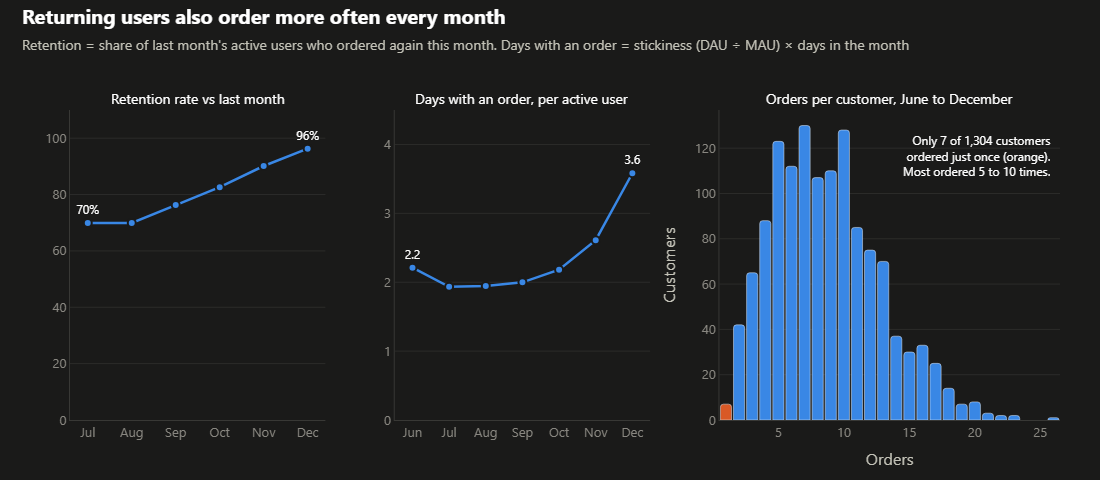

In [8]:
engagement = run_query('''
WITH activity AS (
    SELECT DISTINCT user_id,
           date_trunc('month', order_date)::date AS delivr_month
    FROM orders
),
retention AS (
    SELECT prev.delivr_month + interval '1 month'          AS delivr_month,
           count(cur.user_id) * 100.0 / count(*)           AS retention_pct
    FROM activity AS prev
        LEFT JOIN activity AS cur ON cur.user_id = prev.user_id
            AND cur.delivr_month = (prev.delivr_month + interval '1 month')::date
    WHERE prev.delivr_month < (SELECT max(delivr_month) FROM activity)
    GROUP BY prev.delivr_month
),
active_days AS (
    SELECT date_trunc('month', order_date)::date                                  AS delivr_month,
           count(DISTINCT (user_id, order_date))::numeric / count(DISTINCT user_id) AS days_per_user,
           count(DISTINCT (user_id, order_date))::numeric / count(DISTINCT user_id)
             / extract(day FROM (date_trunc('month', order_date) + interval '1 month - 1 day')) * 100
                                                                                   AS stickiness_pct
    FROM orders
    GROUP BY date_trunc('month', order_date)
)
SELECT ad.delivr_month, ad.days_per_user, ad.stickiness_pct, r.retention_pct
FROM active_days AS ad
    LEFT JOIN retention AS r ON r.delivr_month::date = ad.delivr_month
ORDER BY ad.delivr_month;
''')
engagement["month"] = pd.to_datetime(engagement["delivr_month"]).dt.strftime("%b")

orders_per_customer = run_query('''
SELECT orders,
       count(*) AS customers
FROM (SELECT user_id, count(DISTINCT order_id) AS orders FROM orders GROUP BY user_id) AS t
GROUP BY orders
ORDER BY orders;
''')

fig = make_subplots(rows=1, cols=3, horizontal_spacing=0.07, column_widths=[0.3, 0.3, 0.4],
                    subplot_titles=("Retention rate vs last month", "Days with an order, per active user",
                                    "Orders per customer, June to December"))
ret = engagement.dropna(subset=["retention_pct"])
for col, (df, y, fmt, color) in enumerate([
    (ret, "retention_pct", "{:.0f}%", BLUE),
    (engagement, "days_per_user", "{:.1f}", BLUE),
], start=1):
    labels = [fmt.format(v) if j in (0, len(df) - 1) else "" for j, v in enumerate(df[y])]
    fig.add_scatter(x=df["month"], y=df[y], mode="lines+markers+text", line=dict(color=color, width=2.5),
                    marker=dict(size=8, color=color, line=dict(color=SURFACE, width=2)),
                    text=labels, textposition="top center", textfont=dict(color=INK, size=12),
                    cliponaxis=False, row=1, col=col)
fig.update_yaxes(range=[0, 110], row=1, col=1)
fig.update_yaxes(range=[0, 4.5], row=1, col=2)

once = orders_per_customer.loc[orders_per_customer["orders"] == 1, "customers"].sum()
total_customers = orders_per_customer["customers"].sum()
bar_colors = [ORANGE if n == 1 else BLUE for n in orders_per_customer["orders"]]
fig.add_bar(x=orders_per_customer["orders"], y=orders_per_customer["customers"], marker_color=bar_colors,
            marker_cornerradius=3, row=1, col=3)
fig.add_annotation(x=26, y=128, xref="x3", yref="y3", xanchor="right", yanchor="top", align="right",
                   showarrow=False, font=dict(color=INK, size=12),
                   text=f"Only {once} of {total_customers:,} customers<br>ordered just once (orange).<br>"
                        "Most ordered 5 to 10 times.")
fig.update_xaxes(title="Orders", row=1, col=3)
fig.update_yaxes(title="Customers", row=1, col=3)

style(fig, "Returning users also order more often every month",
      "Retention = share of last month's active users who ordered again this month. "
      "Days with an order = stickiness (DAU ÷ MAU) × days in the month")
for annotation in fig.layout.annotations[:3]:          # the three subplot titles
    annotation.font = dict(size=14, color=INK)
fig.update_layout(bargap=0.15)
save(fig, "06_retention_and_frequency")

<div class="alert alert-block alert-success">

## **4. Eateries**: which restaurant partners make the money?
- **Revenue** = what customers pay (meal price × quantity)
- **Cost** = what Delivr pays the eatery (meal cost × quantity)
- **Profit** = revenue - cost, and **margin** = profit ÷ revenue

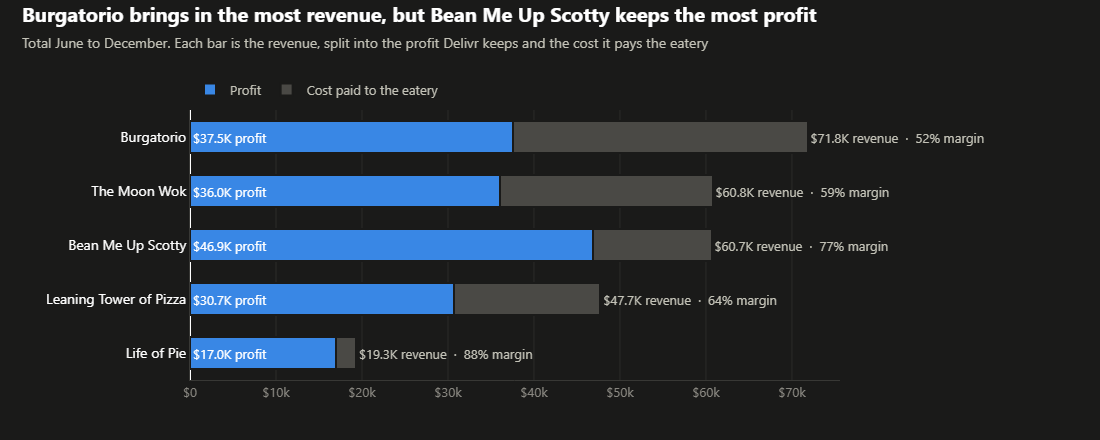

In [9]:
eateries = clean_eatery(run_query('''
SELECT eatery,
       sum(meal_price * order_quantity)                 AS revenue,
       sum(meal_cost * order_quantity)                  AS cost,
       sum((meal_price - meal_cost) * order_quantity)   AS profit
FROM orders
    INNER JOIN meals USING (meal_id)
GROUP BY eatery;
'''))
eateries["margin_pct"] = eateries["profit"] / eateries["revenue"] * 100
eateries = eateries.sort_values("revenue")          # biggest revenue ends up on top

fig = go.Figure()
fig.add_bar(y=eateries["eatery"], x=eateries["profit"], orientation="h", name="Profit", marker_color=BLUE,
            marker_line=dict(color=SURFACE, width=2),
            text=eateries["profit"].map(lambda v: f"${v/1e3:.1f}K profit"), textposition="inside",
            insidetextanchor="start", textfont=dict(color=INK, size=13))
fig.add_bar(y=eateries["eatery"], x=eateries["cost"], orientation="h", name="Cost paid to the eatery",
            marker_color=DIMMED, marker_line=dict(color=SURFACE, width=2),
            text=[f"${r/1e3:.1f}K revenue  ·  {m:.0f}% margin" for r, m in zip(eateries["revenue"], eateries["margin_pct"])],
            textposition="outside", textfont=dict(color=INK_2, size=13), cliponaxis=False)

style(fig, "Burgatorio brings in the most revenue, but Bean Me Up Scotty keeps the most profit",
      "Total June to December. Each bar is the revenue, split into the profit Delivr keeps and the cost it pays the eatery",
      height=440)
fig.update_layout(barmode="stack", showlegend=True, bargap=0.4, margin=dict(l=190, r=260),
                  legend=dict(orientation="h", x=0, y=1.02, traceorder="normal", yanchor="bottom", font=dict(color=INK_2, size=13)))
fig.update_xaxes(tickprefix="$", tickformat="~s", showgrid=True, gridcolor=GRID)
fig.update_yaxes(showgrid=False, tickfont=dict(color=INK, size=14))
save(fig, "07_eatery_revenue_profit")

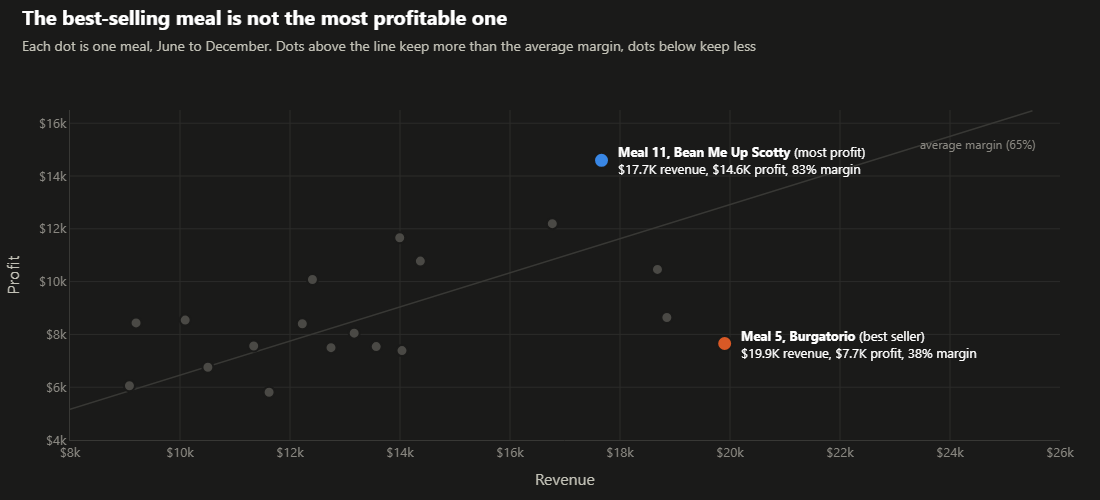

In [10]:
meals = clean_eatery(run_query('''
SELECT meal_id,
       eatery,
       sum(meal_price * order_quantity)                 AS revenue,
       sum((meal_price - meal_cost) * order_quantity)   AS profit,
       (meal_price - meal_cost) / meal_price * 100      AS margin_pct
FROM orders
    INNER JOIN meals USING (meal_id)
GROUP BY meal_id, eatery, meal_price, meal_cost;
'''))
avg_margin = meals["profit"].sum() / meals["revenue"].sum()
best_seller = meals.loc[meals["revenue"].idxmax()]
best_earner = meals.loc[meals["profit"].idxmax()]
others = meals[~meals["meal_id"].isin([best_seller["meal_id"], best_earner["meal_id"]])]

fig = go.Figure()
x_line = np.array([8_000, 25_500])
fig.add_scatter(x=x_line, y=x_line * avg_margin, mode="lines", line=dict(color=BASELINE, width=1.5))
fig.add_annotation(x=24_500, y=24_500 * avg_margin, text=f"average margin ({avg_margin:.0%})",
                   showarrow=False, yshift=-16, font=dict(color=MUTED, size=12))
fig.add_scatter(x=others["revenue"], y=others["profit"], mode="markers",
                marker=dict(size=11, color=DIMMED, line=dict(color=SURFACE, width=2)))
for meal, color, label in [
    (best_seller, EATERY_COLORS[best_seller["eatery"]], "best seller"),
    (best_earner, EATERY_COLORS[best_earner["eatery"]], "most profit"),
]:
    fig.add_scatter(x=[meal["revenue"]], y=[meal["profit"]], mode="markers",
                    marker=dict(size=15, color=color, line=dict(color=SURFACE, width=2)))
    fig.add_annotation(
        x=meal["revenue"], y=meal["profit"], showarrow=False, xanchor="left", xshift=14,
        font=dict(color=INK, size=13), align="left",
        text=(f"<b>Meal {meal['meal_id']}, {meal['eatery']}</b> ({label})<br>"
              # '&#36;' is a literal $; two plain $ signs would switch plotly into LaTeX mode
              f"&#36;{meal['revenue']/1e3:.1f}K revenue, &#36;{meal['profit']/1e3:.1f}K profit, "
              f"{meal['margin_pct']:.0f}% margin"),
    )

style(fig, "The best-selling meal is not the most profitable one",
      "Each dot is one meal, June to December. Dots above the line keep more than the average margin, dots below keep less",
      height=500)
fig.update_xaxes(title="Revenue", tickprefix="$", tickformat="~s", range=[8_000, 26_000], showgrid=True, gridcolor=GRID)
fig.update_yaxes(title="Profit", tickprefix="$", tickformat="~s", range=[4_000, 16_500])
save(fig, "08_meal_revenue_vs_profit")

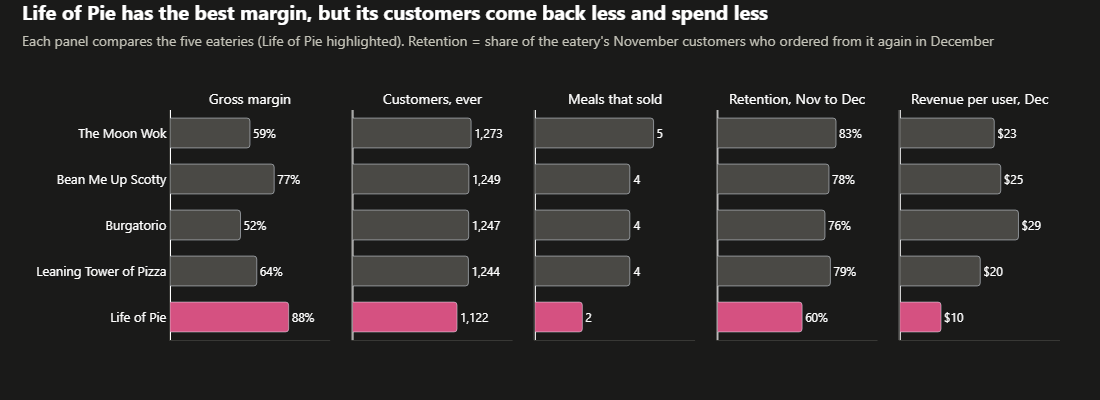

In [11]:
scorecard = clean_eatery(run_query('''
WITH activity AS (
    SELECT DISTINCT eatery,
           user_id,
           date_trunc('month', order_date)::date AS delivr_month
    FROM orders
        INNER JOIN meals USING (meal_id)
),
retention AS (           -- of the eatery's November customers, how many ordered from it again in December?
    SELECT nov.eatery,
           count(dec.user_id) * 100.0 / count(*) AS retention_pct
    FROM activity AS nov
        LEFT JOIN activity AS dec ON dec.user_id = nov.user_id
            AND dec.eatery = nov.eatery
            AND dec.delivr_month = '2018-12-01'
    WHERE nov.delivr_month = '2018-11-01'
    GROUP BY nov.eatery
),
totals AS (
    SELECT eatery,
           sum((meal_price - meal_cost) * order_quantity) * 100
             / sum(meal_price * order_quantity)                                     AS margin_pct,
           count(DISTINCT user_id)                                                  AS customers,
           count(DISTINCT meal_id)                                                  AS meals_sold,
           sum(meal_price * order_quantity) FILTER (WHERE order_date >= '2018-12-01')
             / count(DISTINCT user_id) FILTER (WHERE order_date >= '2018-12-01')    AS arpu_dec
    FROM orders
        INNER JOIN meals USING (meal_id)
    GROUP BY eatery
)
SELECT *
FROM totals
    INNER JOIN retention USING (eatery);
'''))

metrics = [
    ("margin_pct", "Gross margin", "{:.0f}%"),
    ("customers", "Customers, ever", "{:,.0f}"),
    ("meals_sold", "Meals that sold", "{:.0f}"),
    ("retention_pct", "Retention, Nov to Dec", "{:.0f}%"),
    ("arpu_dec", "Revenue per user, Dec", "${:.0f}"),
]
fig = make_subplots(rows=1, cols=len(metrics), horizontal_spacing=0.025, shared_yaxes=True,
                    subplot_titles=[m[1] for m in metrics])
order = scorecard.sort_values("customers")["eatery"].tolist()
scorecard = scorecard.set_index("eatery").loc[order].reset_index()
colors = [MAGENTA if e == "Life of Pie" else DIMMED for e in scorecard["eatery"]]
for i, (col, _, fmt) in enumerate(metrics, start=1):
    fig.add_bar(y=scorecard["eatery"], x=scorecard[col], orientation="h", marker_color=colors,
                marker_cornerradius=3, text=scorecard[col].map(fmt.format), textposition="outside",
                textfont=dict(color=INK, size=12), cliponaxis=False, row=1, col=i)
    fig.update_xaxes(range=[0, scorecard[col].max() * 1.35], showticklabels=False, row=1, col=i)

style(fig, "Life of Pie has the best margin, but its customers come back less and spend less",
      "Each panel compares the five eateries (Life of Pie highlighted). "
      "Retention = share of the eatery's November customers who ordered from it again in December",
      height=400)
fig.update_yaxes(showgrid=False, tickfont=dict(color=INK, size=13))
fig.update_layout(margin=dict(l=170), bargap=0.35)
fig.update_annotations(font=dict(size=14, color=INK))
save(fig, "09_life_of_pie")

<div class="alert alert-block alert-success">

## **5. Customers**: is the profit spread out or does a small group carry it?
- **Pareto analysis**: sort customers (or orders, meals, eateries) from most to least profit and add up their share
- The classic **80/20 rule** says 20% of customers bring 80% of the profit. The closer a curve is to the straight line, the more evenly the profit is spread

Customers: 61% of them make 80% of profit
Orders: 59% of them make 80% of profit
Meals: 74% of them make 80% of profit
Eateries: 80% of them make 80% of profit


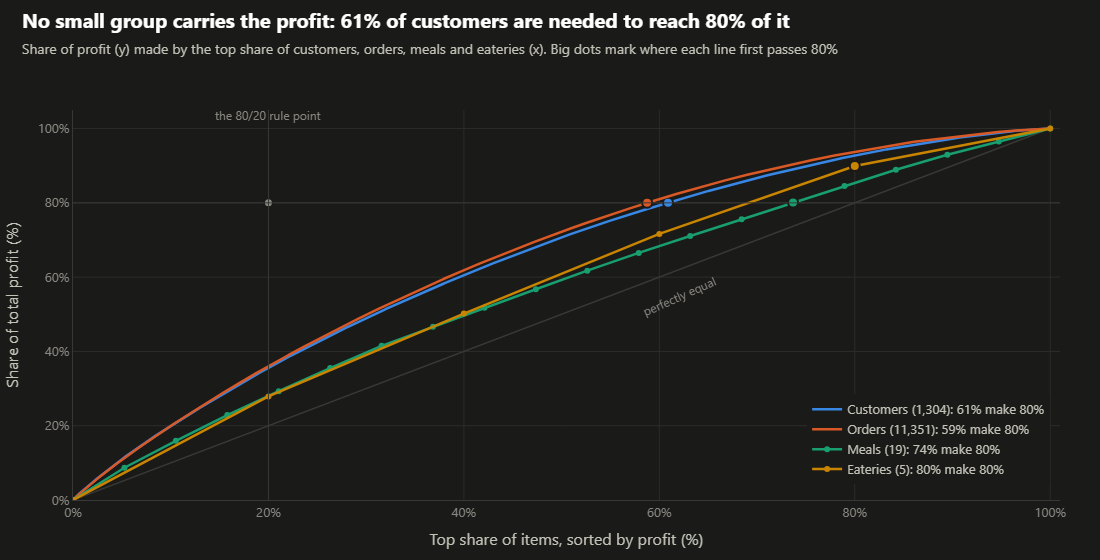

In [12]:
def pareto_curve(level: str) -> pd.DataFrame:
    """Cumulative share of profit when the items of `level` are sorted from most to least profit."""
    df = run_query(f'''
    SELECT {level} AS item,
           sum((meal_price - meal_cost) * order_quantity) AS profit
    FROM orders
        INNER JOIN meals USING (meal_id)
    GROUP BY {level}
    ORDER BY profit DESC;
    ''')
    df["items_pct"] = np.arange(1, len(df) + 1) / len(df) * 100
    df["profit_pct"] = df["profit"].cumsum() / df["profit"].sum() * 100
    # start every curve at (0, 0)
    return pd.concat([pd.DataFrame({"items_pct": [0.0], "profit_pct": [0.0]}), df], ignore_index=True)


levels = [("user_id", "Customers", BLUE), ("order_id", "Orders", ORANGE),
          ("meal_id", "Meals", AQUA), ("eatery", "Eateries", YELLOW)]

fig = go.Figure()
fig.add_scatter(x=[0, 100], y=[0, 100], mode="lines", line=dict(color=BASELINE, width=1.5), showlegend=False)
fig.add_annotation(x=62, y=55, text="perfectly equal", showarrow=False, textangle=-24,
                   font=dict(color=MUTED, size=12))
fig.add_hline(y=80, line=dict(color=BASELINE, width=1))
fig.add_vline(x=20, line=dict(color=BASELINE, width=1))
fig.add_annotation(x=20, y=101, text="the 80/20 rule point", showarrow=False, yanchor="bottom",
                   font=dict(color=MUTED, size=12))
fig.add_scatter(x=[20], y=[80], mode="markers", showlegend=False,
                marker=dict(size=9, color=MUTED, line=dict(color=SURFACE, width=2)))

legend_rows = []
for level, name, color in levels:
    curve = pareto_curve(level)
    reached = curve.loc[curve["profit_pct"] >= 80].iloc[0]       # first item that takes the total past 80%
    needed = reached["items_pct"]
    count = len(curve) - 1
    fig.add_scatter(x=curve["items_pct"], y=curve["profit_pct"], name=f"{name} ({count:,}): {needed:.0f}% make 80%",
                    mode="lines+markers" if count < 30 else "lines",
                    marker=dict(size=6, color=color), line=dict(color=color, width=2.5))
    fig.add_scatter(x=[needed], y=[reached["profit_pct"]], mode="markers", showlegend=False,
                    marker=dict(size=10, color=color, line=dict(color=SURFACE, width=2)))
    legend_rows.append(f"{name}: {needed:.0f}% of them make 80% of profit")

style(fig, "No small group carries the profit: 61% of customers are needed to reach 80% of it",
      "Share of profit (y) made by the top share of customers, orders, meals and eateries (x). Big dots mark where each line first passes 80%",
      height=560)
fig.update_layout(showlegend=True, legend=dict(x=0.99, y=0.04, xanchor="right", yanchor="bottom",
                                               bgcolor=SURFACE, font=dict(color=INK_2, size=13)))
fig.update_xaxes(title="Top share of items, sorted by profit (%)", range=[0, 101], ticksuffix="%",
                 showgrid=True, gridcolor=GRID)
fig.update_yaxes(title="Share of total profit (%)", range=[0, 105], ticksuffix="%")
print("\n".join(legend_rows))
save(fig, "10_profit_concentration")

p10 50 | p25 78 | median 122 | p75 172 | p90 217 | mean 128.9


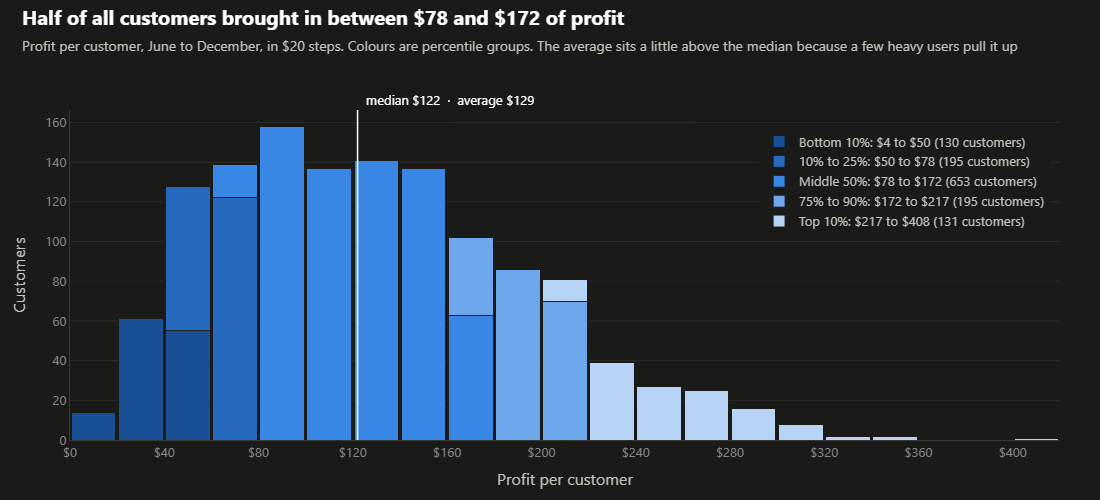

In [13]:
user_profit = run_query('''
SELECT user_id,
       sum((meal_price - meal_cost) * order_quantity) AS profit
FROM orders
    INNER JOIN meals USING (meal_id)
GROUP BY user_id;
''')
p10, p25, p50, p75, p90 = user_profit["profit"].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
mean_profit = user_profit["profit"].mean()

# percentile groups, from the bottom 10% to the top 10% (ordered, so one blue ramp from dark to light)
groups = [
    ("Bottom 10%", -np.inf, p10, "#184f95"),
    ("10% to 25%", p10, p25, "#256abf"),
    ("Middle 50%", p25, p75, "#3987e5"),
    ("75% to 90%", p75, p90, "#6da7ec"),
    ("Top 10%", p90, np.inf, "#b7d3f6"),
]
bins = dict(start=0, end=420, size=20)
fig = go.Figure()
for name, low, high, color in groups:
    part = user_profit[(user_profit["profit"] >= low) & (user_profit["profit"] < high)]
    low_txt = f"${user_profit['profit'].min():.0f}" if low == -np.inf else f"${low:.0f}"
    high_txt = f"${user_profit['profit'].max():.0f}" if high == np.inf else f"${high:.0f}"
    fig.add_histogram(x=part["profit"], xbins=bins, marker_color=color, marker_line=dict(color=SURFACE, width=1),
                      name=usd(f"{name}: {low_txt} to {high_txt} ({len(part)} customers)"))

fig.add_vline(x=p50, line=dict(color=INK, width=1.5))
fig.add_annotation(x=p50, y=1, yref="paper", yanchor="bottom", showarrow=False, xanchor="left", xshift=6,
                   text=usd(f"median ${p50:.0f}  ·  average ${mean_profit:.0f}"), font=dict(color=INK, size=13))

style(fig, f"Half of all customers brought in between ${p25:.0f} and ${p75:.0f} of profit",
      "Profit per customer, June to December, in $20 steps. Colours are percentile groups. "
      "The average sits a little above the median because a few heavy users pull it up", height=500)
fig.update_layout(barmode="stack", bargap=0.05, showlegend=True,
                  legend=dict(x=0.99, y=0.95, xanchor="right", yanchor="top", bgcolor=SURFACE, traceorder="normal",
                              font=dict(color=INK_2, size=13)))
fig.update_xaxes(title="Profit per customer", tickprefix="$", dtick=40)
fig.update_yaxes(title="Customers")
print(f"p10 {p10:.0f} | p25 {p25:.0f} | median {p50:.0f} | p75 {p75:.0f} | p90 {p90:.0f} | mean {mean_profit:.1f}")
save(fig, "11_profit_per_customer")

<div class="alert alert-block alert-success">

## **6. Timing**: when do new users arrive?
- A user's **signup day** is the day of their first order
- **DAU** (daily active users) = distinct users who ordered on that day

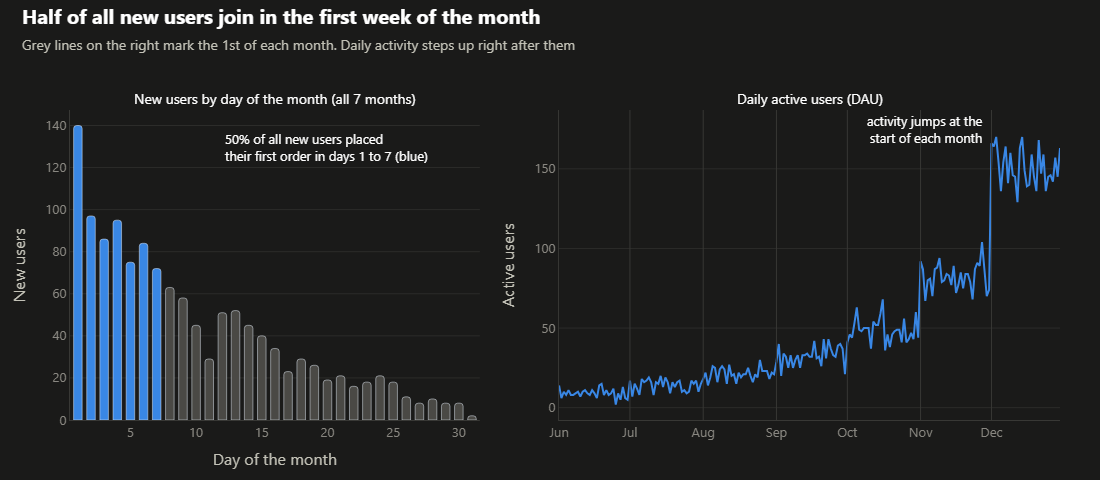

In [14]:
signup_day = run_query('''
WITH regs AS (
    SELECT user_id,
           min(order_date) AS reg_date
    FROM orders
    GROUP BY user_id
)
SELECT extract(day FROM reg_date)::int AS day_of_month,
       count(*)                        AS new_users
FROM regs
GROUP BY day_of_month
ORDER BY day_of_month;
''')
dau = run_query('''
SELECT order_date              AS delivr_day,
       count(DISTINCT user_id) AS dau
FROM orders
GROUP BY order_date
ORDER BY order_date;
''')
dau["delivr_day"] = pd.to_datetime(dau["delivr_day"])

first_week = signup_day["day_of_month"] <= 7
first_week_share = signup_day.loc[first_week, "new_users"].sum() / signup_day["new_users"].sum()

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.08, column_widths=[0.45, 0.55],
                    subplot_titles=("New users by day of the month (all 7 months)",
                                    "Daily active users (DAU)"))
fig.add_bar(x=signup_day["day_of_month"], y=signup_day["new_users"],
            marker_color=[BLUE if f else DIMMED for f in first_week], marker_cornerradius=3, row=1, col=1)
fig.add_annotation(x=12, y=130, xref="x", yref="y", showarrow=False, xanchor="left", align="left",
                   text=f"{first_week_share:.0%} of all new users placed<br>their first order in days 1 to 7 (blue)",
                   font=dict(color=INK, size=13))
fig.update_xaxes(title="Day of the month", dtick=5, range=[0.4, 31.6], row=1, col=1)
fig.update_yaxes(title="New users", row=1, col=1)

fig.add_scatter(x=dau["delivr_day"], y=dau["dau"], mode="lines", line=dict(color=BLUE, width=2), row=1, col=2)
for month_start in pd.date_range("2018-07-01", "2018-12-01", freq="MS"):
    # plain date strings: the image exporter cannot serialise pandas Timestamps in shapes
    fig.add_vline(x=month_start.strftime("%Y-%m-%d"), line=dict(color=BASELINE, width=1), row=1, col=2)
fig.add_annotation(x="2018-12-01", y=175, xref="x2", yref="y2", showarrow=False, xanchor="right",
                   xshift=-6, text="activity jumps at the<br>start of each month", align="right",
                   font=dict(color=INK, size=13))
fig.update_xaxes(tickformat="%b", dtick="M1", row=1, col=2)
fig.update_yaxes(title="Active users", row=1, col=2)

style(fig, "Half of all new users join in the first week of the month",
      "Grey lines on the right mark the 1st of each month. Daily activity steps up right after them")
for annotation in fig.layout.annotations[:2]:
    annotation.font = dict(size=14, color=INK)
save(fig, "12_signup_timing")

<div class="alert alert-block alert-success">

## **Summary**: what the numbers say, and what to do about it
| # | Finding | Suggested action |
|---|---|---|
| 1 | User growth vs the month before fell from 84% to 34%, even though more users join each month | Report the growth **rate** next to the user count, and plan acquisition spend knowing the rate is slowing |
| 2 | 76% of the revenue growth came from more users, 23% from users ordering more often, 1% from bigger orders | Bigger baskets are the untouched lever: test bundles or a minimum order for free delivery |
| 3 | 72% of December's active users were returning customers, and every signup group was 94%+ active in December | Protect this base (loyalty rewards) before paying more for new users |
| 4 | Burgatorio has the most revenue (52% margin), Bean Me Up Scotty the most profit (77% margin) | Rank and promote eateries and meals by **profit**, not revenue. Review the cost of meal 5 (38% margin) |
| 5 | Life of Pie has an 88% margin but the weakest retention (60%) and the lowest revenue per user ($10) | Add meals to its menu (only 2 sell) and promote it; every extra dollar there keeps 88 cents |
| 6 | 61% of customers are needed for 80% of profit; no small group carries the business | Low risk from losing any single customer. Mass-market tactics fit better than VIP programs |
| 7 | 50% of new users place their first order in days 1 to 7 of the month | Line up campaigns and eatery capacity with the first week of each month |